# Patrón 1: Supervisor/Hub-and-Spoke: Customer Support Tickets

### ¿Qué es?
Un **LLM Supervisor** actúa como orquestador central que recibe la tarea del usuario, decide qué **worker agent** especializado debe ejecutarla, y recolecta los resultados. El supervisor usa LLM-based routing — no reglas hardcodeadas — para decidir el siguiente agente a invocar.

Dataset real: Customer Support Ticket Dataset (Kaggle)
Dataset: suraj520/customer-support-ticket-dataset
Contiene ~8,469 tickets de soporte al cliente con columnas:
* Ticket ID
* Customer Name
* Product Purchased
* Ticket Type
* Ticket Subject
* Ticket Description
* Ticket Status
* Resolution
* Ticket Priority
* Ticket Channel

Los tipos de ticket incluyen: Billing inquiry, Technical issue, Product inquiry, Refund request, Cancellation request — exactamente el multi-dominio que necesita el patrón Supervisor.

Columnas relevantes:
* Ticket Type: Billing inquiry | Technical issue | Product inquiry Refund request | Cancellation request
* Ticket Subject: asunto del ticket
* Ticket Description: cuerpo del ticket
* Ticket Priority: Critical | High | Medium | Low
* Resolution: respuesta esperada (ground truth)

Arquitectura:

* Supervisor LLM → determina qué worker agent invocar
* Workers especializados:
        * billing_agent    : Billing inquiry, Refund request
        * technical_agent  : Technical issue
        * orders_agent     : Product inquiry, Cancellation request
        * escalation_agent : tickets Critical sin resolver

* Por qué encaja perfecto con el patrón Supervisor: cada Ticket Type es un dominio distinto que requiere conocimiento especializado → el Supervisor enruta, los workers especializados resuelven.

## Descargar el dataset (requiere cuenta Kaggle)

kaggle datasets download -d suraj520/customer-support-ticket-dataset

unzip customer-support-ticket-dataset.zip -d ./data/

## Instalar dependencias
pip install langgraph langgraph-supervisor langchain-anthropic pandas

Diagrama:

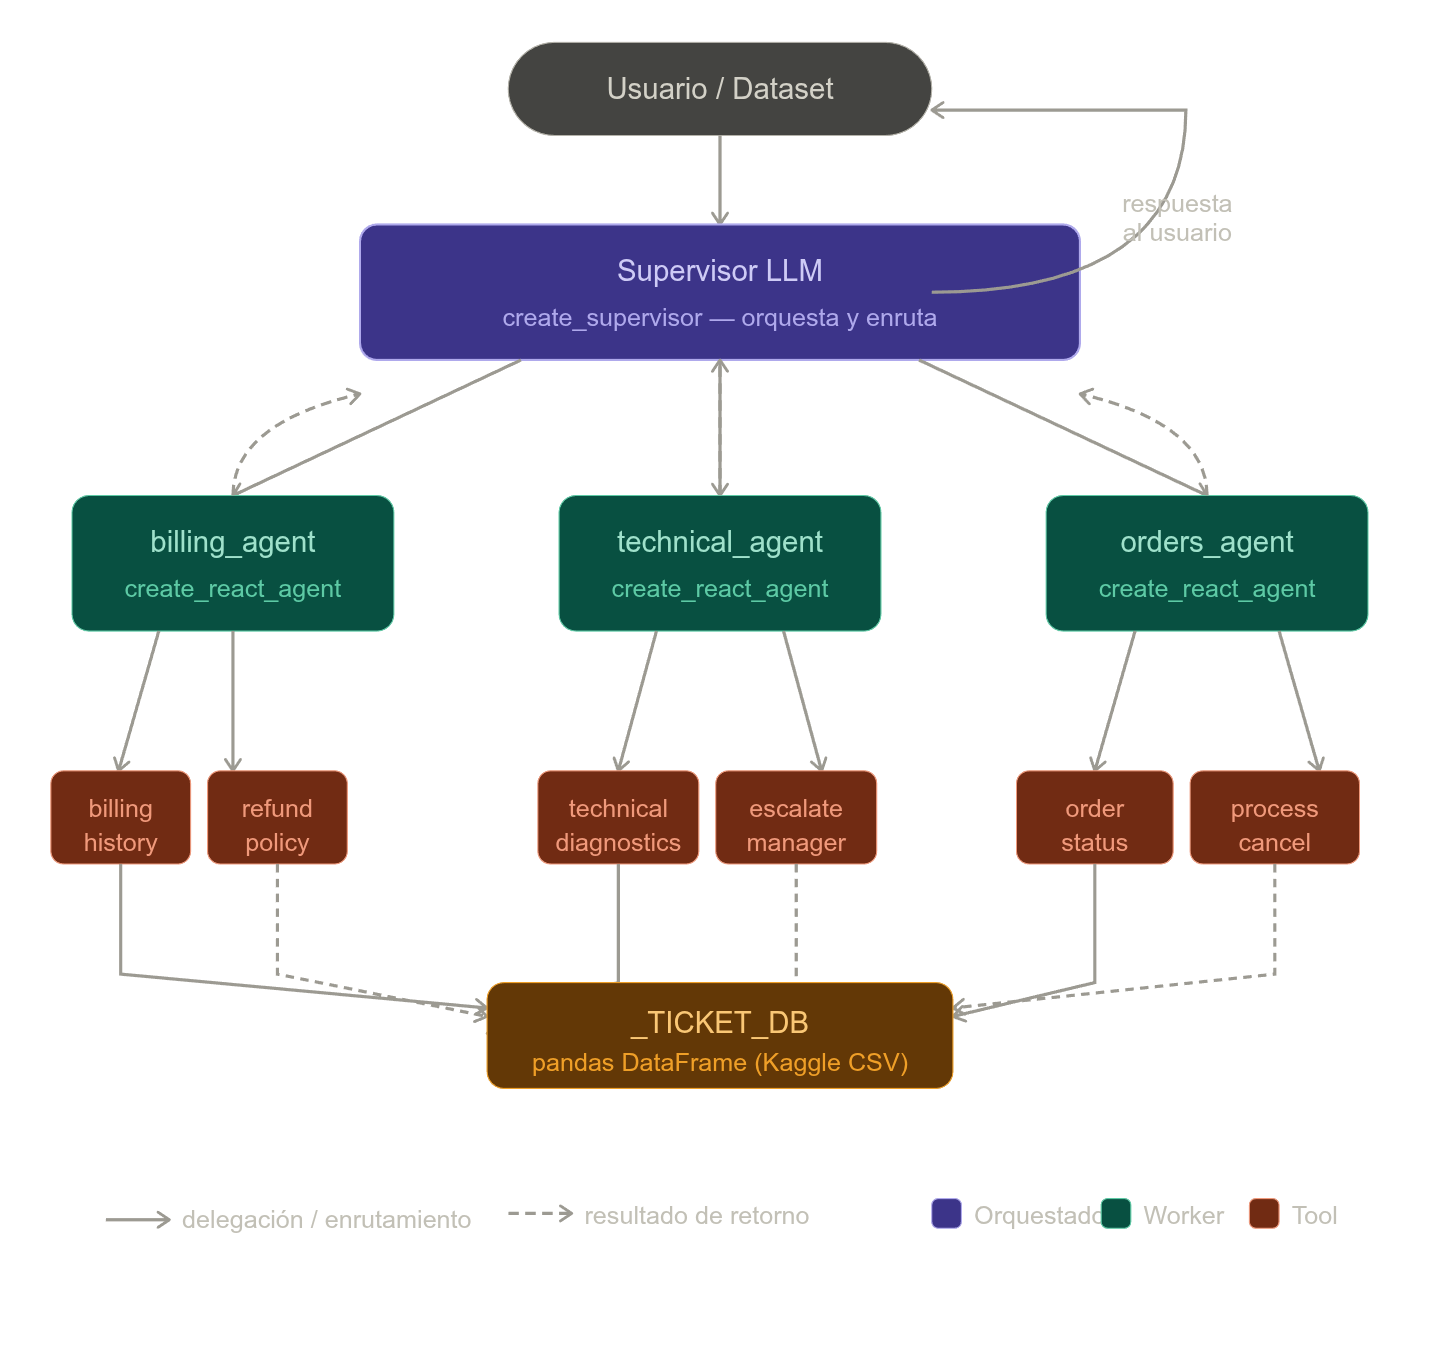


Componentes, Nodos:
|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|Usuario / Dataset|Entrada|Fuente de tickets|Origen de los tickets de soporte. Puede ser un usuario interactivo o el dataset de Kaggle (customer_support_tickets.csv) procesado en lote.|
|Supervisor LLM|Orquestador|Enrutamiento inteligente|Creado con create_supervisor(). Recibe el ticket completo, analiza el tipo de problema mediante LLM y delega al worker especializado correcto. Consolida la respuesta final antes de devolverla al usuario.|
|billing_agent|Worker|Agente de facturación|Creado con create_react_agent(). Especialista en billing inquiries y refund requests. Usa su set de tools para consultar historial del cliente y aplicar políticas de reembolso.|
|technical_agent|Worker|Agente técnico|Creado con create_react_agent(). Resuelve technical issues diagnosticando software, hardware y redes. Puede escalar tickets Critical al gerente si no encuentra resolución en el primer contacto.|
|orders_agent|Worker|Agente de pedidos|Creado con create_react_agent(). Maneja product inquiries y cancellation requests. Aplica estrategias de retención (descuentos, pausas) antes de procesar una cancelación.|
|lookup_billing_history|Tool|Consulta historial|Busca en _TICKET_DB los tickets de facturación previos de un cliente por nombre. Disponible únicamente para billing_agent.|
|lookup_refund_policy|Tool|Política de reembolsos|Devuelve las reglas de reembolso (30 días completo, 31-60 días parcial, etc.). Herramienta estática disponible para billing_agent|
|run_technical_diagnostics|Tool|Diagnóstico técnico|Clasifica el problema en software / hardware / red y devuelve los pasos de diagnóstico correspondientes. Disponible para technical_agent.|
|escalate_to_manager|Tool|Escalación prioritaria|Registra la escalación de un ticket Critical con SLA de 2 horas. Solo la invoca technical_agent cuando no puede resolver en el primer contacto.|
|check_order_status|Tool|Estado del pedido|Busca en _TICKET_DB por Ticket ID y devuelve producto, estado, prioridad y resolución. Disponible para orders_agent|
|process_cancellation|Tool|Gestión de cancelaciones|Genera tres ofertas de retención (descuento, pausa, upgrade) antes de procesar una baja. Disponible para orders_agent|
|_TICKET_DB|Datos|Fuente de datos en memoria|DataFrame global de pandas cargado desde el CSV de Kaggle. Consultado por las tools lookup_billing_history, check_order_status durante la ejecución.|

### Cuándo usarlo
- ✅ Múltiples dominios de expertise (código, búsqueda, datos)
- ✅ Routing inteligente basado en contexto
- ✅ Agentes con HITL donde el supervisor puede pedir confirmación
- ❌ No escala bien con >10 workers (el supervisor se sobrecarga)

In [1]:
!pip install langgraph langgraph-supervisor langchain-anthropic pandas

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.14/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
import pandas as pd
from typing import TypedDict, Annotated, Sequence
from IPython.display import display, Markdown,Image
import operator

In [4]:
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool

# langgraph.prebuilt: create_react_agent → workers especializados (vigente)
from langgraph.prebuilt import create_react_agent

# langgraph_supervisor: create_supervisor → orquestador central
from langgraph_supervisor import create_supervisor

# ─────────────────────────────────────────────
### 3. CARGA Y EXPLORACIÓN DEL DATASET
# ─────────────────────────────────────────────

In [5]:
DATASET_PATH = "./data/customer_support_tickets.csv"

# Variable global para que las tools accedan al dataset
_TICKET_DB: pd.DataFrame = pd.DataFrame()

def load_dataset(path: str = DATASET_PATH) -> pd.DataFrame:
    global _TICKET_DB
    df = pd.read_csv(path)
    _TICKET_DB = df

    display(Markdown("### Vista general del dataset"))
    display(df.head(3))

    print("\n📊 Distribución por tipo de ticket:")
    print(df["Ticket Type"].value_counts().to_string())
    print("\n🎯 Distribución por prioridad:")
    print(df["Ticket Priority"].value_counts().to_string())
    return df

# Intentar cargar; si no existe usar DataFrame vacío (modo demo)
if os.path.exists(DATASET_PATH):
    df = load_dataset(DATASET_PATH)
    USE_REAL_DATASET = True
    print("\n✅ Dataset cargado correctamente")
else:
    print("⚠️  Dataset no encontrado en", DATASET_PATH)
    print("   → Se usarán los tickets de demo de la Sección 7.")
    USE_REAL_DATASET = False

### Vista general del dataset

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0



📊 Distribución por tipo de ticket:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634

🎯 Distribución por prioridad:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063

✅ Dataset cargado correctamente


# ─────────────────────────────────────────────
### 4. HERRAMIENTAS ESPECIALIZADAS POR DOMINIO
# ─────────────────────────────────────────────

In [6]:
@tool
def lookup_billing_history(customer_name: str) -> str:
    """Busca el historial de facturación de un cliente."""
    if _TICKET_DB.empty:
        return f"Historial no disponible para '{customer_name}' (modo demo)"
    mask = _TICKET_DB["Customer Name"].str.contains(customer_name, case=False, na=False)
    rows = _TICKET_DB[mask & _TICKET_DB["Ticket Type"].isin(
        ["Billing inquiry", "Refund request"]
    )]
    if rows.empty:
        return f"No se encontraron registros de facturación para '{customer_name}'"
    summary = rows[["Ticket ID", "Ticket Type", "Ticket Status", "Resolution"]].head(3)
    return f"Últimos registros de facturación:\n{summary.to_string(index=False)}"


@tool
def lookup_refund_policy() -> str:
    """Consulta la política de devoluciones y reembolsos."""
    return """
    POLÍTICA DE REEMBOLSOS:
    • Reembolso completo dentro de 30 días desde la compra
    • Reembolso parcial (50%) entre 31-60 días
    • Sin reembolso después de 60 días (excepto productos defectuosos)
    • Tiempo de procesamiento: 5-10 días hábiles
    """


# ─── Tools del Technical Agent ────────────────────────────────────────────

@tool
def run_technical_diagnostics(product: str, issue_description: str) -> str:
    """Ejecuta diagnóstico técnico para un producto con un problema específico."""
    steps_map = {
        "software": [
            "Verificar versión del software y actualizar",
            "Limpiar caché y archivos temporales",
            "Desinstalar y reinstalar la aplicación",
            "Verificar compatibilidad con el sistema operativo",
        ],
        "network": [
            "Reiniciar router y módem",
            "Verificar configuración DNS (8.8.8.8)",
            "Probar con conexión alternativa (datos móviles)",
            "Verificar firewall y reglas de antivirus",
        ],
        "hardware": [
            "Verificar conexiones físicas del dispositivo",
            "Resetear el dispositivo (30 seg sin corriente)",
            "Actualizar controladores del sistema",
            "Ejecutar diagnóstico de hardware integrado",
        ],
    }
    desc_lower = issue_description.lower()
    category = (
        "network" if any(w in desc_lower for w in ["red", "internet", "wifi", "conexión"])
        else "hardware" if any(w in desc_lower for w in ["dispositivo", "hardware", "físico"])
        else "software"
    )
    steps = steps_map[category]
    return (
        f"Diagnóstico para '{product}' — categoría: {category}\n"
        + "\n".join(f"  ✓ {s}" for s in steps)
    )


@tool
def escalate_to_manager(ticket_id: str, reason: str, priority: str) -> str:
    """Escala un ticket al gerente de soporte para atención prioritaria."""
    return (
        f"🔴 ESCALACIÓN REGISTRADA\n"
        f"Ticket #{ticket_id} escalado | Prioridad: {priority}\n"
        f"Motivo: {reason}\n"
        f"SLA garantizado: respuesta en 2 horas para tickets Critical."
    )


# ─── Tools del Orders Agent ───────────────────────────────────────────────

@tool
def check_order_status(ticket_id: str) -> str:
    """Verifica el estado de un pedido dado su ticket ID."""
    if _TICKET_DB.empty:
        return f"Estado no disponible para ticket #{ticket_id} (modo demo)"
    rows = _TICKET_DB[_TICKET_DB["Ticket ID"].astype(str) == str(ticket_id)]
    if rows.empty:
        return f"No se encontró el ticket ID: {ticket_id}"
    row = rows.iloc[0]
    return (
        f"Estado del ticket #{ticket_id}:\n"
        f"  Producto  : {row.get('Product Purchased', 'N/A')}\n"
        f"  Estado    : {row.get('Ticket Status', 'N/A')}\n"
        f"  Prioridad : {row.get('Ticket Priority', 'N/A')}\n"
        f"  Resolución: {row.get('Resolution', 'Pendiente')}"
    )


@tool
def process_cancellation(customer_name: str, product: str, reason: str) -> str:
    """Procesa una solicitud de cancelación con ofertas de retención."""
    offers = [
        f"30% de descuento durante 3 meses",
        f"Pausar el servicio 1 mes sin costo",
        f"Upgrade gratuito al plan Premium por 2 meses",
    ]
    return (
        f"Solicitud de cancelación — Cliente: {customer_name} | Producto: {product}\n"
        f"Motivo declarado: {reason}\n\n"
        f"Ofertas de retención disponibles:\n"
        + "\n".join(f"  • {o}" for o in offers)
        + "\n\n¿El cliente desea proceder o prefiere una de estas alternativas?"
    )

print("✅ Herramientas definidas:")
print("   Billing  → lookup_billing_history, lookup_refund_policy")
print("   Technical → run_technical_diagnostics, escalate_to_manager")
print("   Orders   → check_order_status, process_cancellation")


✅ Herramientas definidas:
   Billing  → lookup_billing_history, lookup_refund_policy
   Technical → run_technical_diagnostics, escalate_to_manager
   Orders   → check_order_status, process_cancellation


# ─────────────────────────────────────────────
### 5. CONSTRUCCIÓN DEL GRAFO SUPERVISOR
# ─────────────────────────────────────────────

El `Supervisor LLM` enruta cada ticket al worker correcto según el tipo de problema.
Los workers devuelven su respuesta al Supervisor, que la presenta al cliente.


In [ ]:
# ── Patch compatibilidad: langchain-core vs paquete `langchain` ───────────────
# langchain-core consulta globals (verbose/debug/llm_cache) en el módulo `langchain`.
# Si esa versión no los expone -> AttributeError ("module 'langchain' has no
# attribute 'verbose'"). Ejecuta esta celda ANTES de instanciar ChatAnthropic.
import langchain
import langchain_core.globals as _lcg
for _attr, _default in (("verbose", False), ("debug", False), ("llm_cache", None)):
    if not hasattr(langchain, _attr):
        setattr(langchain, _attr, _default)
for _name, _fb in (("get_verbose", False), ("get_llm_cache", None)):
    _orig = getattr(_lcg, _name, None)
    if _orig is not None:
        def _make(orig, fb):
            def _patched():
                try:
                    return orig()
                except AttributeError:
                    return fb
            return _patched
        setattr(_lcg, _name, _make(_orig, _fb))
print("✅ patch compatibilidad langchain aplicado")


In [7]:
def build_supervisor_graph():
    llm = ChatAnthropic(model="claude-sonnet-4-6", temperature=0)

    # ── Worker 1: Billing ────────────────────────────────────────────────
    # create_react_agent (langgraph.prebuilt) sigue vigente para los workers.
    # El prompt del worker se pasa como SystemMessage usando langchain_core.
    billing_agent = create_react_agent(
        llm,
        tools=[lookup_billing_history, lookup_refund_policy],
        name="billing_agent",
        prompt=(
            "Eres un especialista en facturación y reembolsos con 10 años de experiencia. "
            "Resuelve consultas de facturación, gestiona reembolsos y explica políticas "
            "de pago con empatía y precisión. Verifica siempre el historial del cliente. "
            "Responde en español."
        ),
    )

    # ── Worker 2: Technical ──────────────────────────────────────────────
    technical_agent = create_react_agent(
        llm,
        tools=[run_technical_diagnostics, escalate_to_manager],
        name="technical_agent",
        prompt=(
            "Eres un ingeniero de soporte técnico nivel 2. Diagnostica y resuelve "
            "problemas de software, hardware y redes de forma sistemática. "
            "Si el problema es crítico y no se puede resolver en el primer contacto, "
            "escala inmediatamente. Responde en español."
        ),
    )

    # ── Worker 3: Orders ────────────────────────────────────────────────
    orders_agent = create_react_agent(
        llm,
        tools=[check_order_status, process_cancellation],
        name="orders_agent",
        prompt=(
            "Eres un especialista en gestión de pedidos y retención de clientes. "
            "Maneja seguimiento de pedidos y solicitudes de cancelación. "
            "Siempre ofrece alternativas antes de procesar una cancelación. "
            "Responde en español."
        ),
    )

    # ── Supervisor ──────────────────────────────────────────────────────
    # CORRECCIÓN: create_supervisor (langgraph_supervisor) recibe:
    #   - agents como primer argumento posicional (lista de workers compilados)
    #   - model= como keyword (no llm=)
    #   - prompt= como keyword (el system prompt del supervisor)
    #   - output_mode= como keyword
    # NO usa create_react_agent — es una función distinta de langgraph_supervisor.
    supervisor = create_supervisor(
        agents=[billing_agent, technical_agent, orders_agent],
        model=llm,
        prompt=(
            "Eres el supervisor del centro de soporte. Tu rol es ENRUTAR tickets "
            "al agente correcto según el tipo de problema:\n\n"
            "  • billing_agent   → facturación, reembolsos, pagos\n"
            "  • technical_agent → problemas técnicos, errores, diagnósticos\n"
            "  • orders_agent    → pedidos, cancelaciones, consultas de productos\n\n"
            "Analiza el ticket y delega de inmediato. Cuando el agente responda, "
            "presenta su respuesta al cliente de forma clara y profesional. "
            "Tickets con prioridad 'Critical' sin resolver deben ser escalados "
            "por el technical_agent. Responde siempre en español."
        ),
        output_mode="last_message",
    )

    # create_supervisor retorna un StateGraph — hay que compilar antes de usar
    return supervisor.compile()

# Compilar el grafo
graph = build_supervisor_graph()
print("✅ Grafo Supervisor compilado con 3 workers:")
print("   billing_agent | technical_agent | orders_agent")


✅ Grafo Supervisor compilado con 3 workers:
   billing_agent | technical_agent | orders_agent


/tmp/ipykernel_292999/2108893634.py:7: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  billing_agent = create_react_agent(
/tmp/ipykernel_292999/2108893634.py:20: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  technical_agent = create_react_agent(
/tmp/ipykernel_292999/2108893634.py:33: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  orders_agent = create_react_agent(


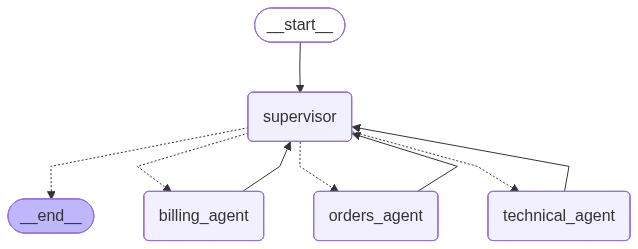

In [8]:
display(Image(graph.get_graph().draw_mermaid_png()))

# ─────────────────────────────────────────────
### 6. PROCESAMIENTO DE TICKETS DEL DATASET
# ─────────────────────────────────────────────

In [9]:
def process_ticket(ticket: dict) -> dict:
    """
    Procesa un ticket a través del grafo Supervisor.

    Args:
        ticket: dict con campos Ticket ID, Ticket Type, Ticket Priority,
                Ticket Subject, Customer Name, Product Purchased, Ticket Description

    Returns:
        dict con ticket_id, ticket_type, priority, agent_response
    """
    user_message = (
        f"TICKET #{ticket.get('Ticket ID', 'N/A')}\n"
        f"Tipo: {ticket.get('Ticket Type', 'N/A')}\n"
        f"Prioridad: {ticket.get('Ticket Priority', 'N/A')}\n"
        f"Asunto: {ticket.get('Ticket Subject', 'N/A')}\n"
        f"Cliente: {ticket.get('Customer Name', 'N/A')}\n"
        f"Producto: {ticket.get('Product Purchased', 'N/A')}\n\n"
        f"Descripción:\n{ticket.get('Ticket Description', 'N/A')}"
    )

    result = graph.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config={"configurable": {"thread_id": f"ticket-{ticket.get('Ticket ID', '0')}"}},
    )

    last_msg = result["messages"][-1]
    response = last_msg.content if isinstance(last_msg.content, str) else str(last_msg.content)

    return {
        "ticket_id"     : ticket.get("Ticket ID"),
        "ticket_type"   : ticket.get("Ticket Type"),
        "priority"      : ticket.get("Ticket Priority"),
        "agent_response": response,
        "ground_truth"  : ticket.get("Resolution", ""),
    }

print("✅ Función process_ticket lista")


✅ Función process_ticket lista


# ─────────────────────────────────────────────
### 7. EVALUACIÓN EN LOTE
# ─────────────────────────────────────────────

In [10]:
DEMO_TICKETS = [
    {
        "Ticket ID"          : 9001,
        "Ticket Type"        : "Billing inquiry",
        "Ticket Priority"    : "High",
        "Ticket Subject"     : "Cobro doble en mi tarjeta",
        "Customer Name"      : "Carlos Mendoza",
        "Product Purchased"  : "Premium Plan",
        "Ticket Description" : (
            "Me cobraron dos veces el mismo mes por mi suscripción Premium. "
            "El cobro aparece el 1 y el 3 de abril por $49.99 cada uno. "
            "Necesito que me devuelvan el cargo duplicado urgente."
        ),
    },
    {
        "Ticket ID"          : 9002,
        "Ticket Type"        : "Technical issue",
        "Ticket Priority"    : "Critical",
        "Ticket Subject"     : "Aplicación no inicia desde ayer",
        "Customer Name"      : "María García",
        "Product Purchased"  : "Desktop App v3.2",
        "Ticket Description" : (
            "Desde ayer la aplicación no abre. Aparece el error: "
            "'FATAL: Unable to load configuration module'. "
            "Intenté reinstalar pero el problema persiste. "
            "Uso Windows 11 con 16 GB RAM. Tengo una presentación mañana."
        ),
    },
    {
        "Ticket ID"          : 9003,
        "Ticket Type"        : "Cancellation request",
        "Ticket Priority"    : "Medium",
        "Ticket Subject"     : "Quiero cancelar mi suscripción",
        "Customer Name"      : "José Rodríguez",
        "Product Purchased"  : "Business Plan",
        "Ticket Description" : (
            "Quiero cancelar mi plan Business porque encontré una solución "
            "más económica. Llevo 8 meses siendo cliente. "
            "¿Cuál es el proceso de cancelación?"
        ),
    },
]

print(f"✅ {len(DEMO_TICKETS)} tickets de demo listos")
for t in DEMO_TICKETS:
    print(f"   #{t['Ticket ID']} | {t['Ticket Type']} | Prioridad: {t['Ticket Priority']}")


✅ 3 tickets de demo listos
   #9001 | Billing inquiry | Prioridad: High
   #9002 | Technical issue | Prioridad: Critical
   #9003 | Cancellation request | Prioridad: Medium


# ─────────────────────────────────────────────
### 8. DEMO INTERACTIVO (ticket individual)
# ─────────────────────────────────────────────

In [11]:
def show_result(result: dict):
    """Muestra el resultado de un ticket de forma formateada en el notebook."""
    priority_emoji = {"Critical": "🔴", "High": "🟠", "Medium": "🟡", "Low": "🟢"}
    type_emoji = {
        "Billing inquiry"     : "💳",
        "Technical issue"     : "🔧",
        "Cancellation request": "❌",
        "Product inquiry"     : "📦",
        "Refund request"      : "💰",
    }
    p_icon = priority_emoji.get(result["priority"], "⚪")
    t_icon = type_emoji.get(result["ticket_type"], "📋")

    md = f"""
---
### {t_icon} Ticket \#{result['ticket_id']} — {result['ticket_type']} {p_icon}
**Prioridad:** {result['priority']}

**Respuesta del agente:**

{result['agent_response']}
"""
    display(Markdown(md))

# ── Procesar ticket 1: Billing ─────────────────────────────────────────────
print("Procesando ticket #9001 (Billing inquiry)...")
result1 = process_ticket(DEMO_TICKETS[0])
show_result(result1)


<>:22: SyntaxWarning: invalid escape sequence '\#'
<>:22: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_292999/1002585844.py:22: SyntaxWarning: invalid escape sequence '\#'
  """


Procesando ticket #9001 (Billing inquiry)...



---
### 💳 Ticket \#9001 — Billing inquiry 🟠
**Prioridad:** High

**Respuesta del agente:**

---

Carlos, el equipo de **Facturación** ya tiene tu caso activo con **prioridad High**. En cuanto nos proporciones los datos solicitados (correo, ID de cliente o últimos 4 dígitos de tu tarjeta), procederemos con el reembolso de **$49.99** a la brevedad posible.

¿Puedes compartir esa información? 🙏


In [12]:
# ── Procesar ticket 2: Technical ─────────────────────────────────────────
print("Procesando ticket #9002 (Technical issue - Critical)...")
result2 = process_ticket(DEMO_TICKETS[1])
show_result(result2)

Procesando ticket #9002 (Technical issue - Critical)...



---
### 🔧 Ticket \#9002 — Technical issue 🔴
**Prioridad:** Critical

**Respuesta del agente:**

---

María, entendemos perfectamente la urgencia de tu situación con la presentación de mañana. 🎯 El ticket ha sido marcado como **CRÍTICO** y el equipo técnico está trabajando en ello con **máxima prioridad**. ¿Tienes alguna pregunta adicional o necesitas asistencia con otro tema?


In [18]:
# ── Procesar ticket 3: Cancellation ──────────────────────────────────────
print("Procesando ticket #9003 (Cancellation request)...")
result3 = process_ticket(DEMO_TICKETS[2])
show_result(result3)

Procesando ticket #9003 (Cancellation request)...



---
### ❌ Ticket \#9003 — Cancellation request 🟡
**Prioridad:** Medium

**Respuesta del agente:**

---

**José**, el agente de pedidos ha revisado tu caso y te presenta las opciones anteriores. Tienes dos caminos:

✅ **Aceptar una oferta especial** → Indícanos cuál te interesa y la activamos de inmediato.
❌ **Proceder con la cancelación** → Te guiaremos paso a paso en el proceso.

¿Qué prefieres hacer? 😊


## 10. Procesamiento en lote (requiere dataset de Kaggle)

Procesa una muestra estratificada del dataset real.
Saltear esta celda si no descargaste el dataset.

In [13]:
if not USE_REAL_DATASET:
    print("⚠️  Dataset no disponible. Descarga el CSV de Kaggle y vuelve a correr la Sección 4.")
else:
    N_SAMPLES = 10   # ← ajusta según tu límite de API

    # Muestreo estratificado: proporcional por tipo de ticket
    samples = (
        df.groupby("Ticket Type", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max(1, N_SAMPLES // 5))))
        .head(N_SAMPLES)
        .reset_index(drop=True)
    )

    print(f"Procesando {len(samples)} tickets del dataset real...")
    print("Tipos incluidos:", samples["Ticket Type"].value_counts().to_dict())

    batch_results = []
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n[{i}/{len(samples)}] Ticket #{row['Ticket ID']} — {row['Ticket Type']}")
        try:
            res = process_ticket(row.to_dict())
            batch_results.append(res)
            show_result(res)
        except Exception as e:
            print(f"  ❌ Error: {e}")
            batch_results.append({
                "ticket_id"     : row.get("Ticket ID"),
                "ticket_type"   : row.get("Ticket Type"),
                "priority"      : row.get("Ticket Priority"),
                "agent_response": f"ERROR: {e}",
                "ground_truth"  : row.get("Resolution", ""),
            })

    # Guardar resultados
    results_df = pd.DataFrame(batch_results)
    os.makedirs("./data", exist_ok=True)
    results_df.to_csv("./data/supervisor_results.csv", index=False)
    print("\n✅ Resultados guardados en ./data/supervisor_results.csv")
    display(results_df[["ticket_id", "ticket_type", "priority"]].head())


/tmp/ipykernel_292999/381444785.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), max(1, N_SAMPLES // 5))))


Procesando 10 tickets del dataset real...
Tipos incluidos: {'Billing inquiry': 2, 'Cancellation request': 2, 'Product inquiry': 2, 'Refund request': 2, 'Technical issue': 2}

[1/10] Ticket #4263 — Billing inquiry



---
### 💳 Ticket \#4263 — Billing inquiry 🟡
**Prioridad:** Medium

**Respuesta del agente:**

## ⚠️ Ticket Incompleto — Acción Requerida

He detectado un problema con el **Ticket #4263** antes de proceder con el enrutamiento.

---

### 🔍 Problema Identificado

La descripción del ticket contiene **variables sin reemplazar**:

- `{product_purchased}` aparece **2 veces** en el cuerpo del mensaje y **no fue sustituida** por el valor real del producto.

Aunque el ticket indica que el producto es una **LG Washing Machine**, la descripción parece ser una **plantilla genérica mal procesada**, lo que genera inconsistencias adicionales:

| Campo | Valor |
|---|---|
| **Tipo declarado** | Billing inquiry |
| **Asunto declarado** | Hardware issue |
| **Descripción** | Hace referencia a "limpiar caché y datos de una app" — algo inconsistente con una lavadora |

---

### 📋 Acción Necesaria

Para poder asistir correctamente al cliente **Steven Lara**, necesito que se proporcione:

1. ✅ **Descripción real del problema** (sin variables de plantilla sin reemplazar)
2. ✅ **Tipo de problema correcto**: ¿Es un problema de facturación, técnico o relacionado con un pedido?
3. ✅ **Confirmación del producto** afectado

Una vez recibida la información correcta, procederé a enrutar el ticket al agente correspondiente de inmediato. 🙏



[2/10] Ticket #8306 — Billing inquiry



---
### 💳 Ticket \#8306 — Billing inquiry 🟠
**Prioridad:** High

**Respuesta del agente:**

---

## ✅ Respuesta al Cliente — Christopher Bailey

---

Estimado **Christopher Bailey**,

Gracias por contactarnos respecto a su **GoPro Hero**. Hemos revisado su caso (Ticket **#8306**) y queremos informarle lo siguiente:

### 🔍 Sobre su problema de acceso

Entendemos que está experimentando un error de **"Credenciales Inválidas"** a pesar de usar la información correcta, y que ya realizó un **restablecimiento de fábrica** sin obtener resultados.

Le recomendamos los siguientes pasos mientras nuestro equipo especializado revisa su caso:

1. ✅ Intente **restablecer su contraseña** desde la opción *"¿Olvidaste tu contraseña?"* en el portal de GoPro
2. ✅ Pruebe acceder desde un **navegador diferente** o en modo incógnito
3. ✅ Verifique que no haya **bloqueos de red o firewall** en su conexión
4. ✅ Intente acceder usando **datos móviles** para descartar problemas de red local

### 📌 Estado de su caso

Su ticket ha sido **escalado con prioridad High** y recibirá una respuesta de nuestro equipo especializado en un plazo máximo de **2 horas**.

Lamentamos los inconvenientes ocasionados y estamos comprometidos a resolver su situación a la brevedad.

Atentamente,
**Centro de Soporte al Cliente**


...


---
### 🔧 Ticket \#7628 — Technical issue 🟢
**Prioridad:** Low

**Respuesta del agente:**

[]



[10/10] Ticket #3032 — Technical issue



---
### 🔧 Ticket \#3032 — Technical issue 🔴
**Prioridad:** Critical

**Respuesta del agente:**

---

## ✉️ Respuesta al Cliente

---

Estimado **Michael Webb**,

Gracias por contactarnos. Hemos recibido su ticket **#3032** y lo hemos asignado a nuestro equipo técnico con **prioridad crítica**.

Sin embargo, hemos notado que la descripción de su caso contiene información incompleta. Para poder asistirle de manera efectiva, le pedimos amablemente que nos proporcione:

- 📌 **¿Cuál es el comportamiento exacto del dispositivo?** (no enciende, no responde, emite sonidos extraños, etc.)
- 📌 **¿Qué versión de software tenía antes de la actualización?**
- 📌 **¿Cuándo exactamente comenzó el problema?**

Nuestro equipo técnico le contactará en un plazo máximo de **2 horas** para resolver su caso.

Lamentamos los inconvenientes ocasionados.

Atentamente,
**Centro de Soporte al Cliente** 🛠️



✅ Resultados guardados en ./data/supervisor_results.csv


,ticket_id,ticket_type,priority
0,4263,Billing inquiry,Medium
1,8306,Billing inquiry,High
2,708,Cancellation request,Critical
3,4389,Cancellation request,Critical
4,764,Product inquiry,Medium


## 11. Análisis del routing (si corriste el batch)


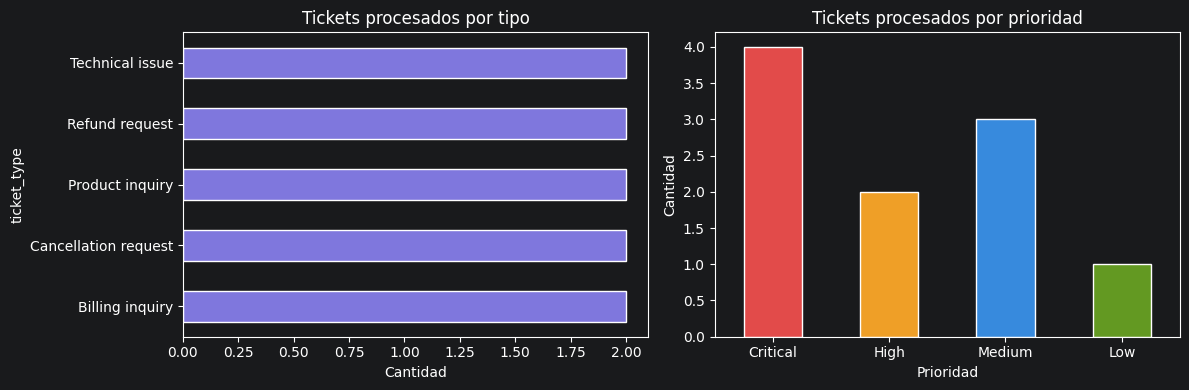

📊 Gráfico guardado en ./data/routing_analysis.png


In [14]:
if not USE_REAL_DATASET:
    print("⚠️  Disponible solo con dataset real (Sección 10).")
else:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Distribución por tipo
    results_df["ticket_type"].value_counts().plot(
        kind="barh", ax=axes[0], color="#7F77DD", edgecolor="white"
    )
    axes[0].set_title("Tickets procesados por tipo")
    axes[0].set_xlabel("Cantidad")

    # Distribución por prioridad
    priority_order = ["Critical", "High", "Medium", "Low"]
    priority_colors = {"Critical": "#E24B4A", "High": "#EF9F27", "Medium": "#378ADD", "Low": "#639922"}
    counts = results_df["priority"].value_counts().reindex(priority_order, fill_value=0)
    counts.plot(
        kind="bar", ax=axes[1],
        color=[priority_colors.get(p, "#888") for p in priority_order],
        edgecolor="white"
    )
    axes[1].set_title("Tickets procesados por prioridad")
    axes[1].set_xlabel("Prioridad")
    axes[1].set_ylabel("Cantidad")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig("./data/routing_analysis.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("📊 Gráfico guardado en ./data/routing_analysis.png")


## 12. Prueba con tu propio ticket


In [15]:
# ── Personaliza este ticket y ejecuta la celda ───────────────────────────
my_ticket = {
    "Ticket ID"          : 9999,
    "Ticket Type"        : "Technical issue",      # cambia el tipo aquí
    "Ticket Priority"    : "High",
    "Ticket Subject"     : "Error al exportar reportes",
    "Customer Name"      : "Ana López",
    "Product Purchased"  : "Analytics Pro",
    "Ticket Description" : (
        "Cuando intento exportar un reporte a PDF el sistema lanza un error 500. "
        "Esto comenzó después de la actualización del martes. "
        "Necesito los reportes para reunión de directivos el viernes."
    ),
}

print(f"Procesando ticket personalizado #{my_ticket['Ticket ID']}...")
my_result = process_ticket(my_ticket)
show_result(my_result)


Procesando ticket personalizado #9999...



---
### 🔧 Ticket \#9999 — Technical issue 🟠
**Prioridad:** High

**Respuesta del agente:**

---

Estimada **Ana López**, aquí el resumen de la gestión de tu ticket:

---

## 🎫 Ticket #9999 — Error al exportar reportes | Analytics Pro

### 🔍 Diagnóstico del Equipo Técnico

El equipo ha identificado que el **error 500** está relacionado con un **fallo en el módulo de exportación PDF** introducido en la actualización del martes. Se trata de un problema conocido que ya está siendo trabajado.

---

### 🛠️ Soluciones Inmediatas Recomendadas

Mientras se despliega el parche correctivo, puedes intentar lo siguiente:

> 1. **Limpiar el caché** de la aplicación: `Configuración → Caché → Limpiar todo`
> 2. **Exportar en formato alternativo** (Excel o CSV) como solución temporal para tu reunión del viernes
> 3. **Verificar** si el error ocurre en todos los reportes o solo en algunos específicos

---

### 📅 Compromisos del Equipo

| Acción | Plazo estimado |
|--------|---------------|
| 🔔 Contacto del gerente de soporte | Máximo **2 horas** |
| 🩹 Despliegue del parche correctivo | Antes del **viernes** |

---

> ⚠️ **Nota importante:** Dado que tienes una reunión de directivos el viernes, hemos marcado este caso con **alta prioridad** para garantizar que tengas los reportes listos a tiempo.

¿Necesitas ayuda adicional o tienes alguna otra consulta, Ana? 😊
